# MMMM 6-DOF hex: the 6 moment modes (within-element multipole basis)

The **Multipole Magnetic Moment Method (MMMM)** assigns each hexahedral surface-charge
element a 6-dimensional moment basis in the face-charge space `R^6` (one uniform surface
charge `sigma` per face). This notebook visualizes **each of the 6 modes** as a field,
*within and around a single cube element*.

The 6 modes are exactly **1 monopole + 3 dipole + 2 quadrupole** (the C++
`momentResidualEigenmodes`, `src/core/rad_interaction.cpp`). The symbolic rank proof is
`packages/radia-mcp/src/radia_mcp/mathematica/basis_functions/six_face_charge_multipole.wls`:
the charge -> multipole-moment map has rank 4 (mono+dipole), 6 (+quadrupole, adds exactly 2),
6 (+octupole, adds 0) -- the element has **no independent content beyond mono + dipole + 2
quadrupole**, and a distorted hex only **rotates** the quadrupole pair.

MCP knowledge: `mcp__radia-ngsolve__mmm_core` topics `multipole_modes` (physics) and
`multipole_modes_viz` (this recipe).

## Two senses of "mode" (important)

**(1) Moment basis** -- `momentResidualEigenmodes`, the MMMM solver's per-element DOF
(monopole + 3 dipole + (nF-4) quadrupole; the common N-face implementation for
hex(6)/wedge(5)/pyramid(5)). **This notebook builds the moment basis.**

**(2) Field eigenmodes** -- SVD/eig of the element's field operator ("what field each
mode radiates, ranked by strength"). On the CUBE the field eigenvalues are degenerate
(3 dipole, 2 quadrupole), so the eigenmodes are an arbitrary basis and the moment basis
is just a symmetry-adapted representative. **Distort the hex** (shear / non-cubic) and
the degeneracy SPLITS -> the eigenmodes become unique and the **quadrupole pair ROTATES**
(still exactly mono + 3 dipole + 2 quadrupole, no octupole):

![Distorted hex field eigenmodes](moment_mode_distorted_3d.png)

**TET is the exception** -- not the face-charge moment path; it is the classic 3-DOF
dipole MMM, so its modes are the 3 principal axes of its 3x3 demag tensor
(`rad.GetInteractMatrix`): isotropic for a regular tet, three distinct eigenvalues for
an irregular tet (NOT x/y/z, NOT a moment basis).

*API caveat:* `rad.GetInteractMatrix` returns zeros for the MSC hex/pyramid/wedge now
(EIEM2 dense blocks removed), so the lab `the retired VIM prototype inventory recorded in docs/hdiv_vim/vim_examples_retirement_results.json`
SVD-of-N path is stale for them; build a field-energy Gram for their field eigenmodes
(the 3-DOF tet demag tensor still works).

## 1. Build the 6 modes as face-charge vectors

Monopole functional `Ae[f]` (face area), dipole functionals `Ae[f]*d_f[k]`
(`d_f` = face center - element center), Gram-Schmidt orthonormalized; extend with the
standard basis -> the 2 residual eigenmodes are the quadrupole modes.

In [1]:
import numpy as np

L = 0.01; H = L / 2.0                      # cube edge / half-edge (m)
# faces [+x,-x,+y,-y,+z,-z]: (outward normal, center, in-plane axes u,v)
FACES = [
    (np.array([ 1.,0,0]), np.array([ H,0,0]), np.array([0,1.,0]), np.array([0,0,1.])),
    (np.array([-1.,0,0]), np.array([-H,0,0]), np.array([0,1.,0]), np.array([0,0,1.])),
    (np.array([0, 1.,0]), np.array([0, H,0]), np.array([1.,0,0]), np.array([0,0,1.])),
    (np.array([0,-1.,0]), np.array([0,-H,0]), np.array([1.,0,0]), np.array([0,0,1.])),
    (np.array([0,0, 1.]), np.array([0,0, H]), np.array([1.,0,0]), np.array([0,1.,0])),
    (np.array([0,0,-1.]), np.array([0,0,-H]), np.array([1.,0,0]), np.array([0,1.,0])),
]
Ae = np.array([L * L] * 6)
dctr = np.array([f[1] for f in FACES])     # face center - origin

def build_modes():
    def gram_schmidt(vecs, existing):
        out = list(existing)
        for v in vecs:
            v = v.astype(float).copy()
            for bvec in out:
                v -= np.dot(bvec, v) * bvec
            n = np.linalg.norm(v)
            if n > 1e-9:
                out.append(v / n)
        return out
    u0 = Ae.copy()
    u1 = Ae * dctr[:, 0]; u2 = Ae * dctr[:, 1]; u3 = Ae * dctr[:, 2]
    base = gram_schmidt([u0, u1, u2, u3], [])
    full = gram_schmidt([np.eye(6)[i] for i in range(6)], base)
    names = ["monopole","dipole-x","dipole-y","dipole-z","quadrupole-1","quadrupole-2"]
    return names, np.array(full[:6])

names, modes = build_modes()
np.set_printoptions(precision=3, suppress=True)
print("face order [+x,-x,+y,-y,+z,-z]")
for nm, m in zip(names, modes):
    print(f"  {nm:13s} {m}")

face order [+x,-x,+y,-y,+z,-z]
  monopole      [0.408 0.408 0.408 0.408 0.408 0.408]
  dipole-x      [ 0.707 -0.707  0.     0.     0.     0.   ]
  dipole-y      [ 0.     0.     0.707 -0.707  0.     0.   ]
  dipole-z      [ 0.     0.     0.     0.     0.707 -0.707]
  quadrupole-1  [ 0.577  0.577 -0.289 -0.289 -0.289 -0.289]
  quadrupole-2  [ 0.  -0.   0.5  0.5 -0.5 -0.5]


## 2. Evaluate a mode's field with the EXACT analytic kernel

A mode's field is `H(r) = (1/4pi) sum_f sigma_f * (field of the uniformly charged square
face)`. Split each square into 2 triangles and use the lab closed form
`FieldFromChargedTriangleLocal` (**van Oosterom-Strackee 1983** solid-angle/arctan normal
term + log edge terms; Wilton et al. 1984; `src/core/rad_interaction.cpp:1495`).

This is **exact** -- it matches `radia` `rad.Fld` of a uniform-`M` hex to ~1e-14 and removes
the ~1e-4 near-surface error of a Gauss quadrature.

In [2]:
def H_charged_triangle(obs, V0, V1, V2, sigma=1.0):
    """Analytic H (without 1/4pi) of a uniformly charged flat triangle, obs (N,3)."""
    obs = np.atleast_2d(np.asarray(obs, float))
    V0, V1, V2 = map(lambda x: np.asarray(x, float), (V0, V1, V2))
    e1 = V1 - V0; e2 = V2 - V0
    a = e1 / np.linalg.norm(e1)
    c = np.cross(e1, e2); cc = c / np.linalg.norm(c); b = np.cross(cc, a)
    XY = np.array([[0.0, 0.0], [np.linalg.norm(e1), 0.0], [e2 @ a, e2 @ b]])
    DS = np.zeros(3); AM = np.zeros(3); XD = np.zeros(3); YD = np.zeros(3)
    for j in range(3):
        l = (j + 1) % 3
        dx = XY[l,0]-XY[j,0]; dy = XY[l,1]-XY[j,1]
        if abs(dx) < 1e-20: dx = 1e-20
        DS[j] = np.hypot(dx, dy); AM[j] = dy/dx; XD[j] = -dx/DS[j]; YD[j] = dy/DS[j]
    EPSG = DS.max()*1e-12
    d = obs - V0[None,:]
    EE1 = d@a; EE2 = d@b; EE3 = d@cc; Z = EE3
    X = EE1[:,None]-XY[:,0][None,:]; Y = EE2[:,None]-XY[:,1][None,:]
    Hh = Y*X; E = (EE3**2)[:,None]+X**2; R = np.sqrt(X**2+Y**2+(EE3**2)[:,None])
    AL = np.empty_like(X)
    for j in range(3):
        jp1 = (j+1)%3
        AL[:,j] = np.log(np.clip((R[:,j]+R[:,jp1]-DS[j])/(R[:,j]+R[:,jp1]+DS[j]), 1e-300, None))
    HH1 = sigma*(-(YD[None,:]*AL).sum(1)); HH2 = sigma*(-(XD[None,:]*AL).sum(1))
    Zs = np.where(np.abs(Z) > EPSG, Z, 1.0); AT = np.empty_like(X); BT = np.empty_like(X)
    for j in range(3):
        jp1 = (j+1)%3
        AT[:,j] = (AM[j]*E[:,j]-Hh[:,j])/(Zs*R[:,j]); BT[:,j] = (AM[j]*E[:,jp1]-Hh[:,jp1])/(Zs*R[:,jp1])
    HH3 = np.where(np.abs(Z) > EPSG, sigma*(-np.arctan(AT).sum(1)+np.arctan(BT).sum(1)), 0.0)
    return HH1[:,None]*a + HH2[:,None]*b + HH3[:,None]*cc

def _tris(face):
    n, ctr, u, v = face
    c00=ctr-H*u-H*v; c10=ctr+H*u-H*v; c11=ctr+H*u+H*v; c01=ctr-H*u+H*v
    return [(c00,c10,c11),(c00,c11,c01)]
_TRIS = [(i,t) for i in range(6) for t in _tris(FACES[i])]

def H_of_charge(sigma_faces, obs):
    obs = np.atleast_2d(obs); acc = np.zeros((len(obs),3))
    for i,(T0,T1,T2) in _TRIS:
        if abs(sigma_faces[i]) > 1e-15:
            acc += sigma_faces[i]*H_charged_triangle(obs, T0,T1,T2, 1.0)
    return acc/(4.0*np.pi)

# cross-check the dipole-x charge pattern against radia (uniform M = e_x hex, external H)
try:
    import radia as rad
    rad.UtiDelAll()
    v = [[-H,-H,-H],[H,-H,-H],[H,H,-H],[-H,H,-H],[-H,-H,H],[H,-H,H],[H,H,H],[-H,H,H]]
    hexM = rad.ObjHexahedron(v, [1.0,0.0,0.0])
    P = np.array([[0.03,0,0],[0,0.025,0.01],[0.02,0.02,0.02]])
    Ha = H_of_charge(np.array([1.,-1,0,0,0,0]), P)
    Hr = np.array([rad.Fld(hexM,"h",p.tolist()) for p in P])
    print("analytic dipole-x vs radia (external H): rel =",
          f"{np.linalg.norm(Ha-Hr)/np.linalg.norm(Hr):.2e}")
    rad.UtiDelAll()
except Exception as e:
    print("radia cross-check skipped:", e)

analytic dipole-x vs radia (external H): rel = 1.45e-14


## 3. The 6 modes as 2D streamplots (one per mode, on its natural plane)

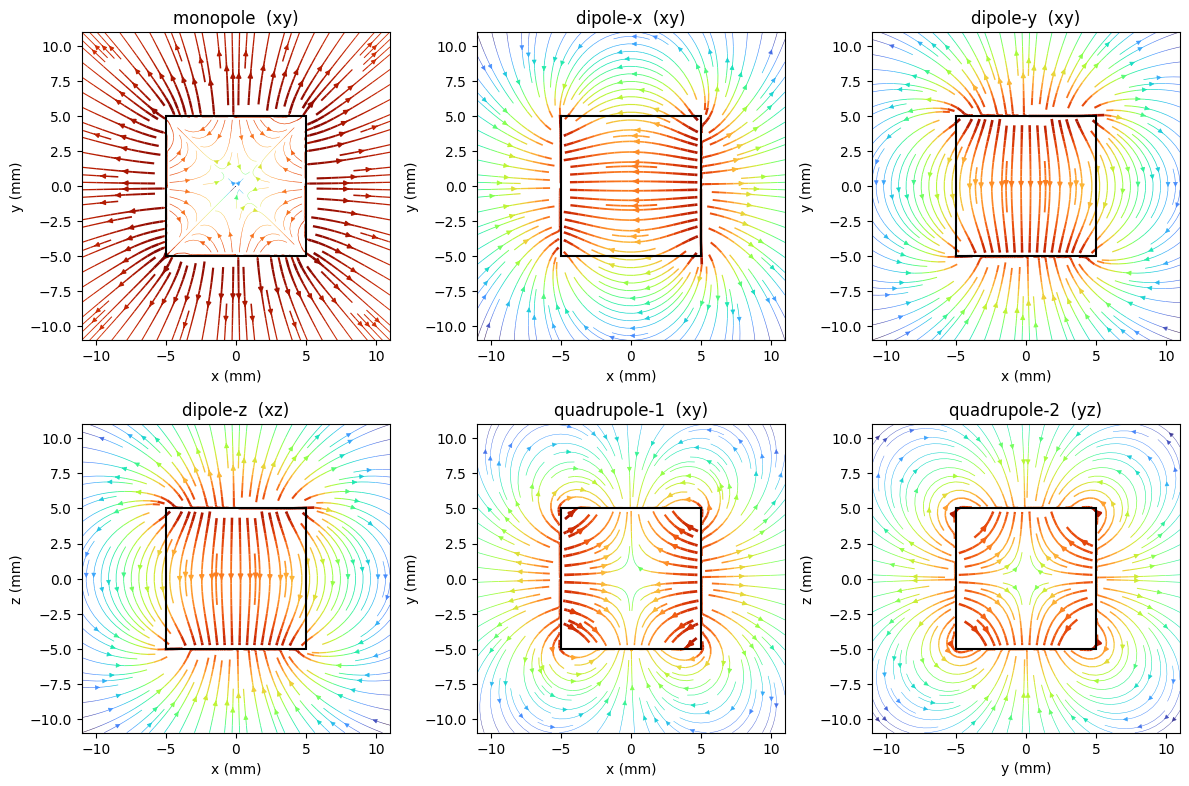

In [3]:
import matplotlib.pyplot as plt
AX = {"xz":(0,2,"x","z",1), "yz":(1,2,"y","z",0), "xy":(0,1,"x","y",2)}
RNG, NG = 0.011, 80

def plane_field(sigma, plane):
    i,j,la,lb,kfix = AX[plane]
    g = np.linspace(-RNG, RNG, NG); A,B = np.meshgrid(g,g)
    obs = np.zeros((NG*NG,3)); obs[:,i]=A.ravel(); obs[:,j]=B.ravel()
    Hf = H_of_charge(sigma, obs)
    return g, Hf[:,i].reshape(NG,NG), Hf[:,j].reshape(NG,NG), (la,lb,i,j)

def pick(sigma):
    return max(("xz","yz","xy"), key=lambda p: float(np.nanmean(plane_field(sigma,p)[1]**2+plane_field(sigma,p)[2]**2)))

fig, axes = plt.subplots(2,3, figsize=(12,8))
for ax, nm, sig in zip(axes.ravel(), names, modes):
    p = pick(sig); g,Ua,Ub,(la,lb,i,j) = plane_field(sig,p); mag = np.hypot(Ua,Ub)
    ax.streamplot(g*1e3, g*1e3, Ua, Ub, color=np.log10(mag+1e-30), cmap="turbo", density=1.4,
                  linewidth=np.clip(1.3*mag/np.nanpercentile(mag,92)+0.25,0.25,2.0), arrowsize=0.7)
    ax.add_patch(plt.Rectangle((-H*1e3,-H*1e3), L*1e3, L*1e3, fill=False, ec="k", lw=1.5, zorder=5))
    ax.set_title(f"{nm}  ({p})"); ax.set_xlabel(f"{la} (mm)"); ax.set_ylabel(f"{lb} (mm)"); ax.set_aspect("equal")
fig.tight_layout(); plt.show()

## 4. GMSH 3D streamlines + a double-click `.msh`

For a genuine **3D** view, sample `H` on a structured grid, write a `.msh` with a unit-field
view `U = H/|H|` (so `Plugin(StreamLines)` integrates uniform arc-length) plus a `|H|` view,
and run `Plugin(StreamLines)` seeded on the 3 coordinate planes **forward and backward**.

To ship a **double-clickable** `.msh` (Windows `.msh` -> `gmsh.bat`):

- **GOTCHA**: `gmsh.view.write()` of a list-based StreamLines view to `.msh` falls back to
  MSH 2.2. Instead **extract** the polylines (`gmsh.view.getListData` -> `"SL"` =
  `x0,x1,y0,y1,z0,z1,v0,v1` per segment) and **re-emit** a clean MSH v4.1 of `Line2`
  (`gmsh_type 1`) elements + a `$NodeData "|H|"`. Add the cube edges as `Line2` pinned to
  `|H|_max` so the element box is visible. The reusable `PayloadV41` emitter is in
  `radia.gmsh_post_export`.
- Write a companion `<file>.msh.opt` (GMSH **auto-loads** it on open): `General.RotationX/Y/Z`,
  `General.Orthographic = 0`, `View[0].ColormapNumber`, `Mesh.Lines = 0` -> double-clicking the
  `.msh` opens straight to the 3D streamline view.

The six double-clickable files are `<mode>_modes_3d.msh` (+ `.msh.opt`).

![MMMM 6-DOF hex 3D streamlines of the 6 moment modes](moment_mode_streamlines_3d.png)

*3D GMSH StreamLines of the 6 modes (cube element). 2D-plane version:*
`moment_mode_streamlines_2d.png`.